# Supplementary: Ridge regression details

| Panel | What |
|-------|------|
| A | CV R² distributions — all 5 non-HPF LFP targets, waveform-only model |
| B | Predicted vs actual — all 5 LFP targets, waveform-only model (sig cells only) |
| C | Pre vs post-spike β correlation — justifies averaging pre/post |
| D | Full beta profile — all 8 waveform features, all LFP targets |
| E | Top target × feature combos with large effect and mixed cell direction |

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets,
    aggregate_population,
    average_pre_post_betas,
    run_population_tests,
    run_r2_tests,
    plot_r2_summary_boxplot,
    build_population_scatter,
    plot_beta_full_summary,
    plot_beta_heterogeneity_top_combos,
    plot_beta_pre_post_scatter,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
ALPHA     = 0.05
MIN_CELLS = 5

# internal keys (match target_labels after stripping Pre/Post)
ALL_FEATS_KEYS = [
    'LFP Amp', 'LFP Std', 'Exponent', 'Gamma AUC', 'Theta AUC',
]
ALL_FEATS_DISPLAY = [
    'LFP Amp', 'LFP Std', 'Aperiodic Exponent', 'Gamma AUC', 'Theta AUC',
]

In [2]:
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

# Exclude only HPF variants — keep all non-HPF targets including LFP Amp
keep = [i for i, tl in enumerate(target_labels) if '(HPF)' not in tl]
target_names  = [target_names[i]  for i in keep]
target_labels = [target_labels[i] for i in keep]

r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

print('Significant R² targets (Waveform only):', sig_r2_targets)
print(f'Cells: {len(cell_ids)}')
print('Active targets:', target_labels)

Merged: 39 cells  |  14 targets (Pre+Post abs + HPF amp/std, no BL-corrected or Δ)
R² > 0 Wilcoxon: 30 (target × predictor_set) pairs  |  p<0.05: 9  (each target independent, no cross-target correction)
 target_label      predictor_set  n_cells  median_r2  mean_r2    p_str stars
  Pre LFP Amp      Waveform only       39   0.037000 0.076709 < 0.0001   ***
  Pre LFP Amp Waveform + Log ISI       39   0.044731 0.084265 < 0.0001   ***
  Pre LFP Std      Waveform only       39   0.005852 0.028585   0.0003   ***
  Pre LFP Std Waveform + Log ISI       39   0.009939 0.036655 < 0.0001   ***
 Post LFP Amp      Waveform only       39   0.026567 0.072955 < 0.0001   ***
 Post LFP Amp Waveform + Log ISI       39   0.037312 0.080850 < 0.0001   ***
 Post LFP Std      Waveform only       39   0.004980 0.026950   0.0012    **
 Post LFP Std Waveform + Log ISI       39   0.010076 0.038331 < 0.0001   ***
Post Exponent Waveform + Log ISI       39   0.001942 0.006646   0.0193     *
Beta tests restricted to 4 

In [3]:
# Average pre+post betas (justified by Panel A: ρ ≥ 0.96 for all features)
beta_avg, avg_tns, avg_tls = average_pre_post_betas(beta_pop, target_names, target_labels)
df_tests_avg = run_population_tests(
    beta_avg, avg_tns, avg_tls,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
print('Averaged targets:', avg_tls)

Beta consistency: 40 pairs across 5 targets  |  t-test p<0.05: 2  |  Wilcoxon p<0.05: 4
target_label    feature  n  median_beta  p_str stars_wilcox
     LFP Amp   Ramp Amp 39    -0.006710 0.0322            *
     LFP Amp  Infl. Amp 39     0.013091 0.0386            *
     LFP Amp  Sharpness 39    -0.013995 0.0347            *
   Gamma AUC Peak Width 37    -0.006645 0.0455            *
Averaged targets: ['LFP Amp', 'LFP Std', 'Gamma AUC', 'Exponent', 'Theta AUC']


## Panel A — CV R² distributions (waveform-only model, all targets)

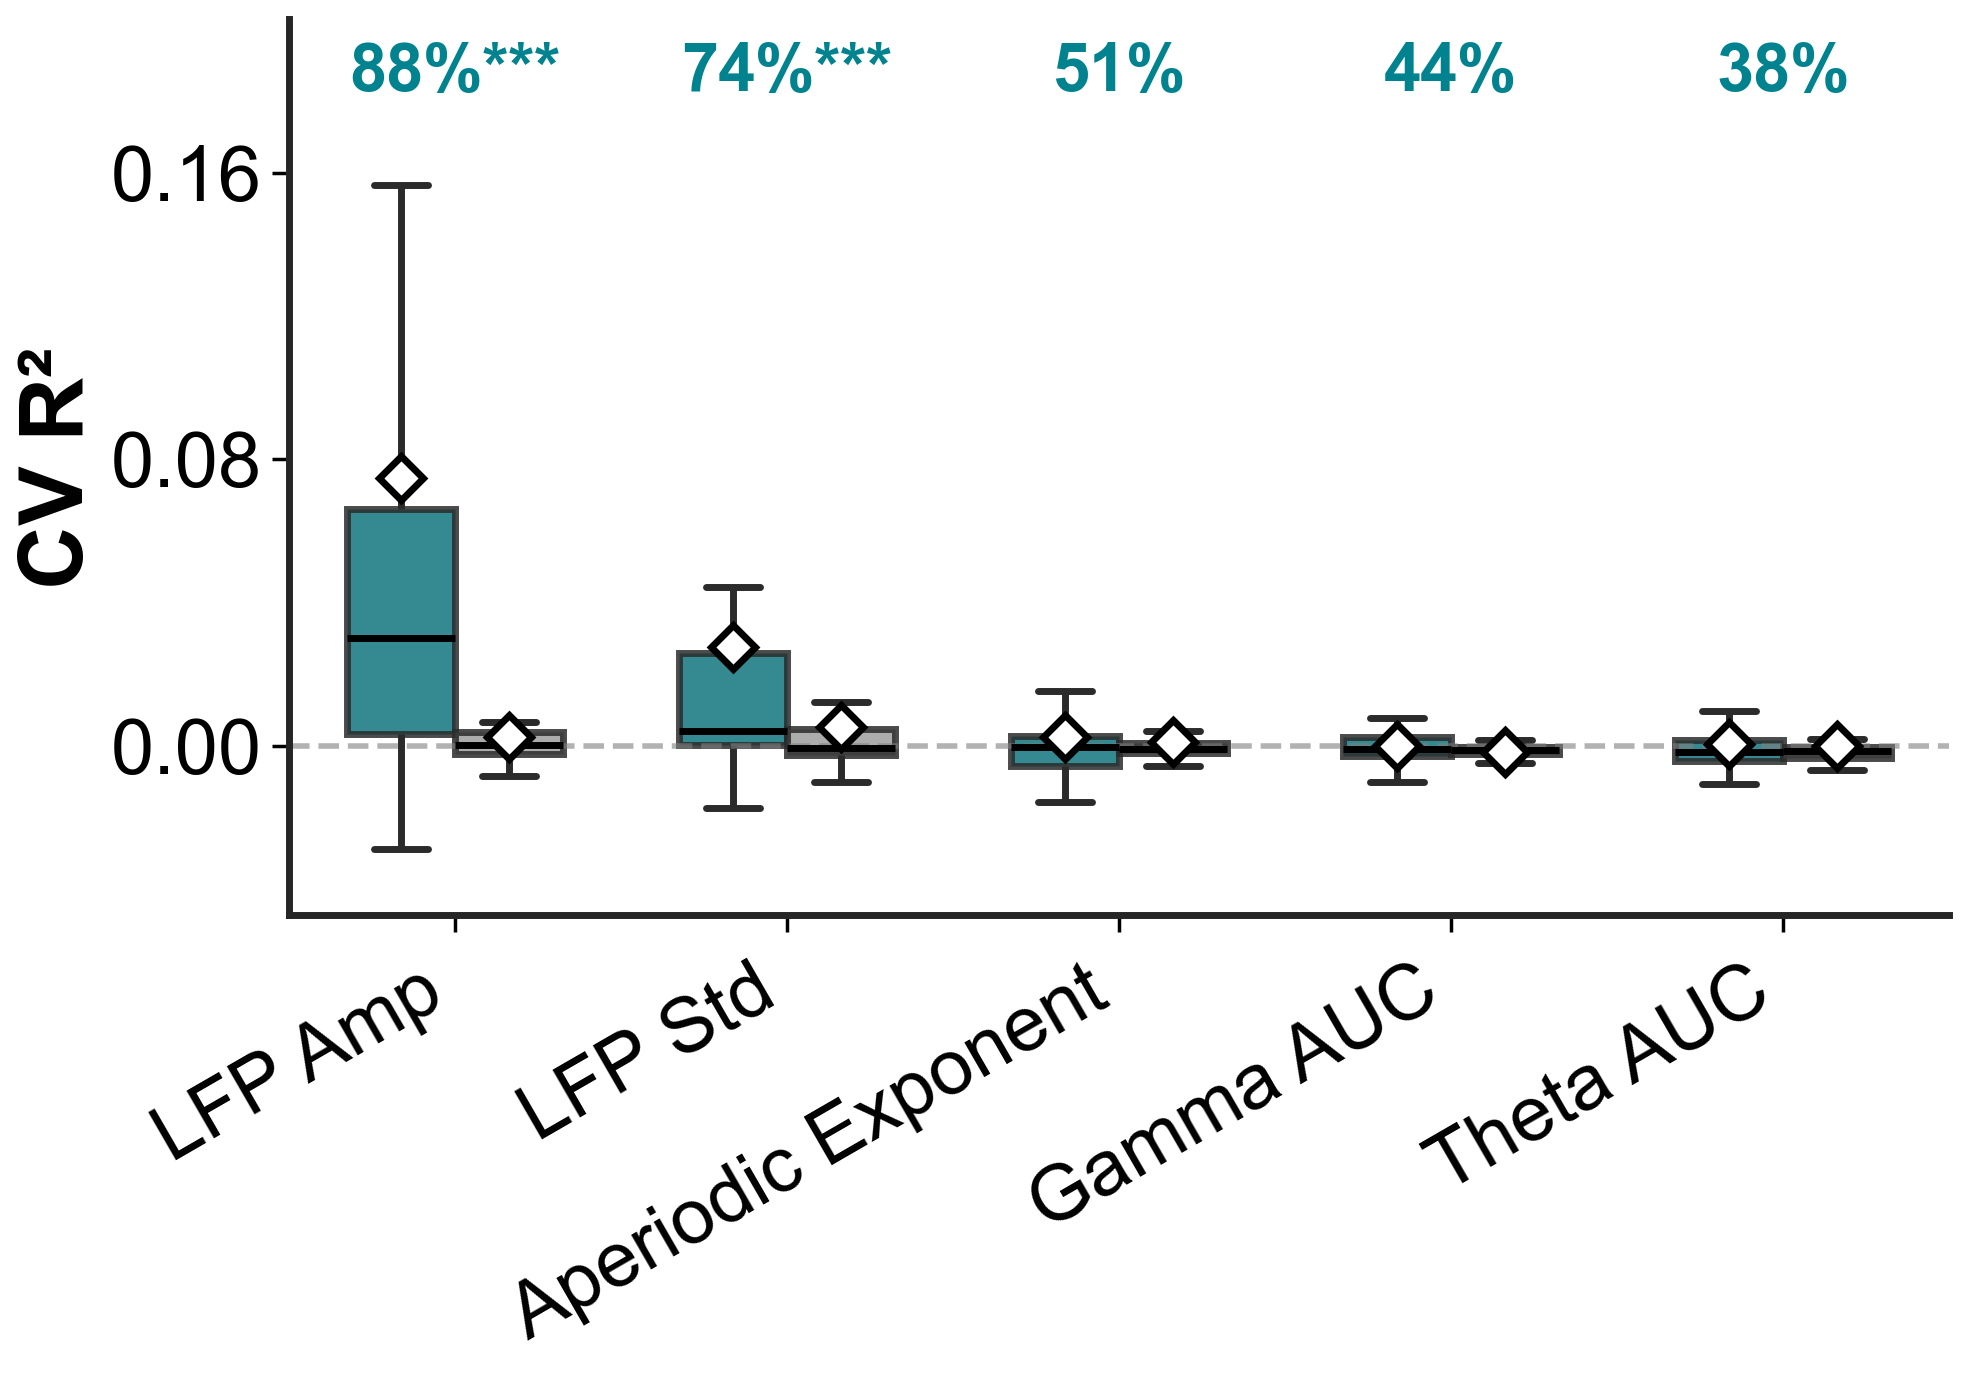

(<Figure size 1000x700 with 1 Axes>,
 array([[<Axes: ylabel='CV R²'>]], dtype=object),
 <Figure size 280x220 with 1 Axes>)

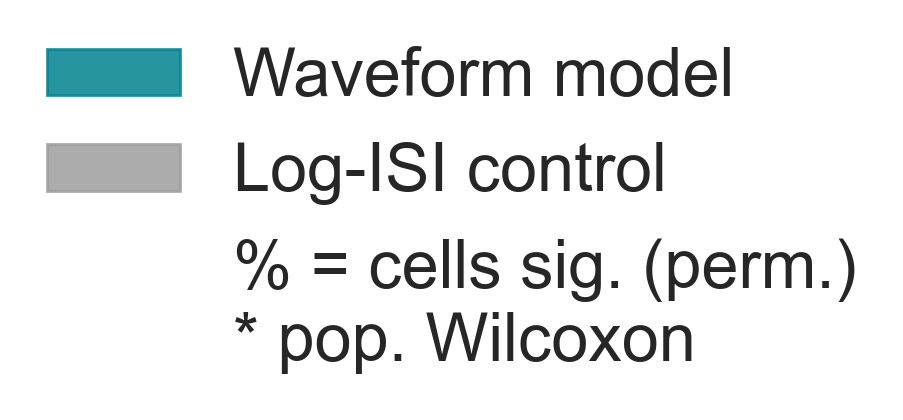

In [4]:
plot_r2_summary_boxplot(r2_pop, sig_pop, df_r2, target_names, target_labels,
                        feat_order=ALL_FEATS_KEYS,
                        feat_display_names=ALL_FEATS_DISPLAY,
                        control_predictor_set='Log ISI only',
                        combine_windows=True)

## Panel B — Predicted vs actual (all LFP targets, waveform-only model)

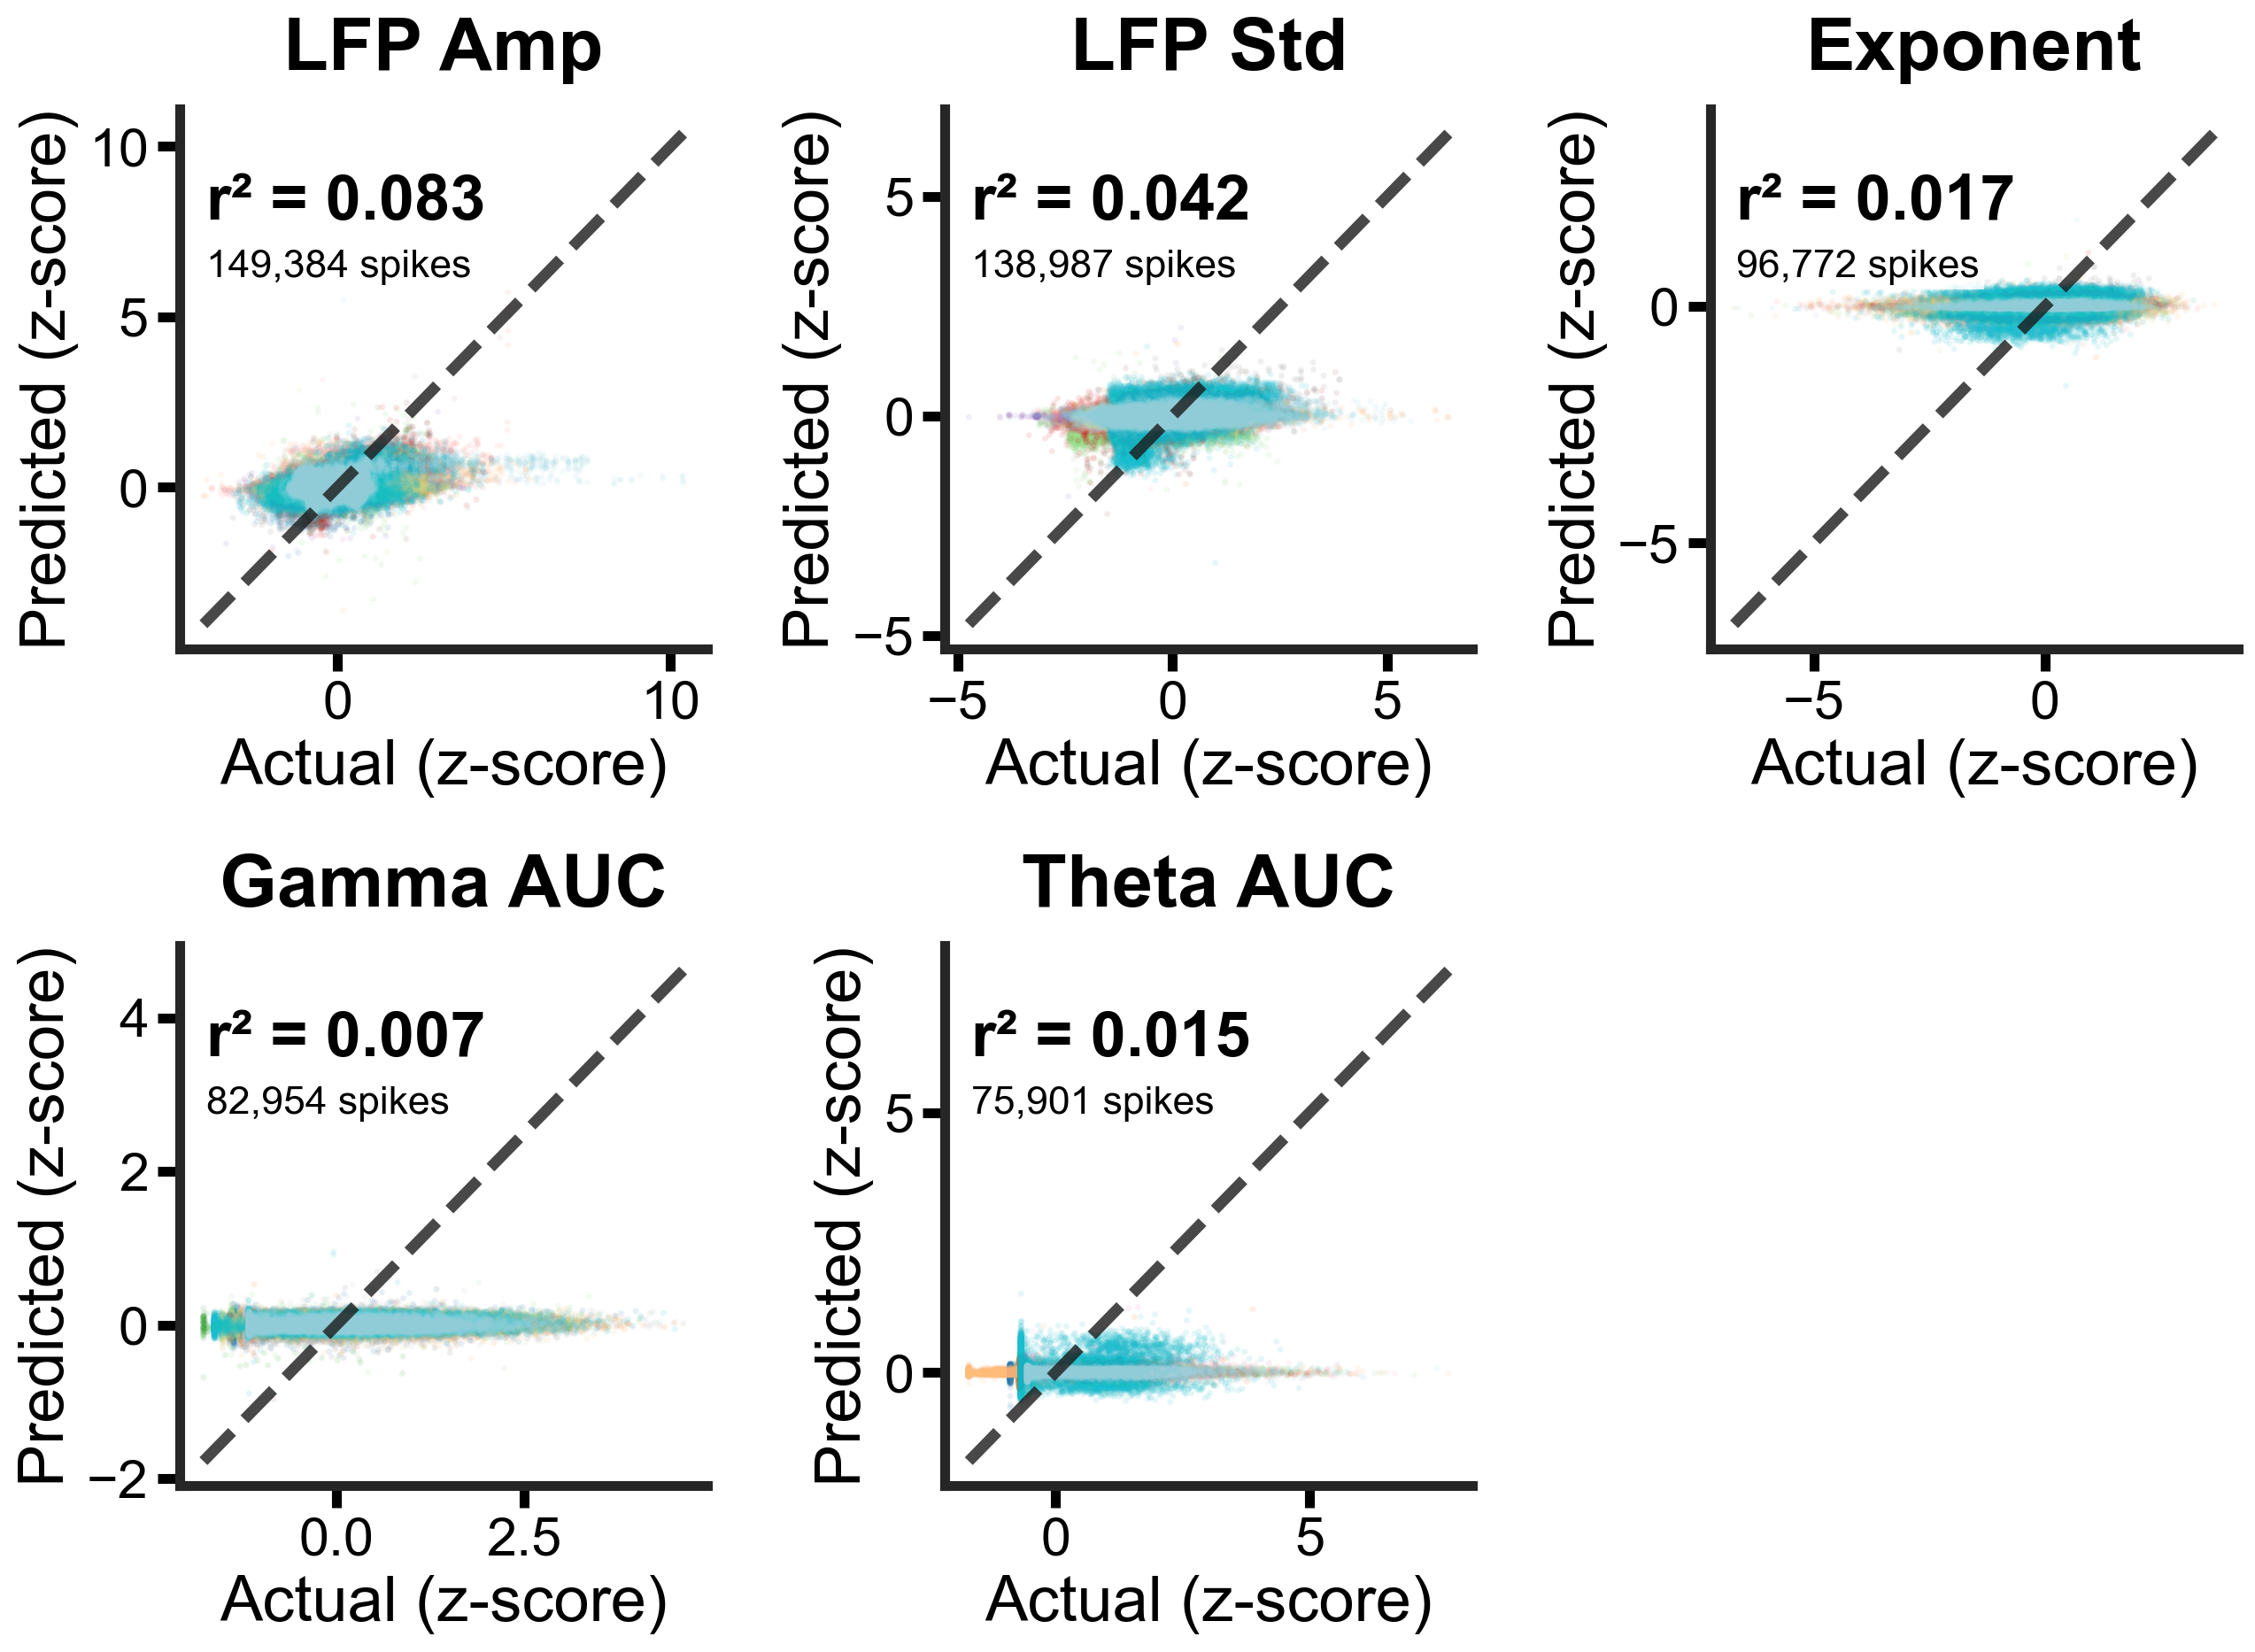

In [5]:
build_population_scatter(all_results, cell_ids, target_names, target_labels,
                         feat_order=ALL_FEATS_KEYS,
                         win_order=['Pre'])

## Panel C — Pre vs post-spike β correlation

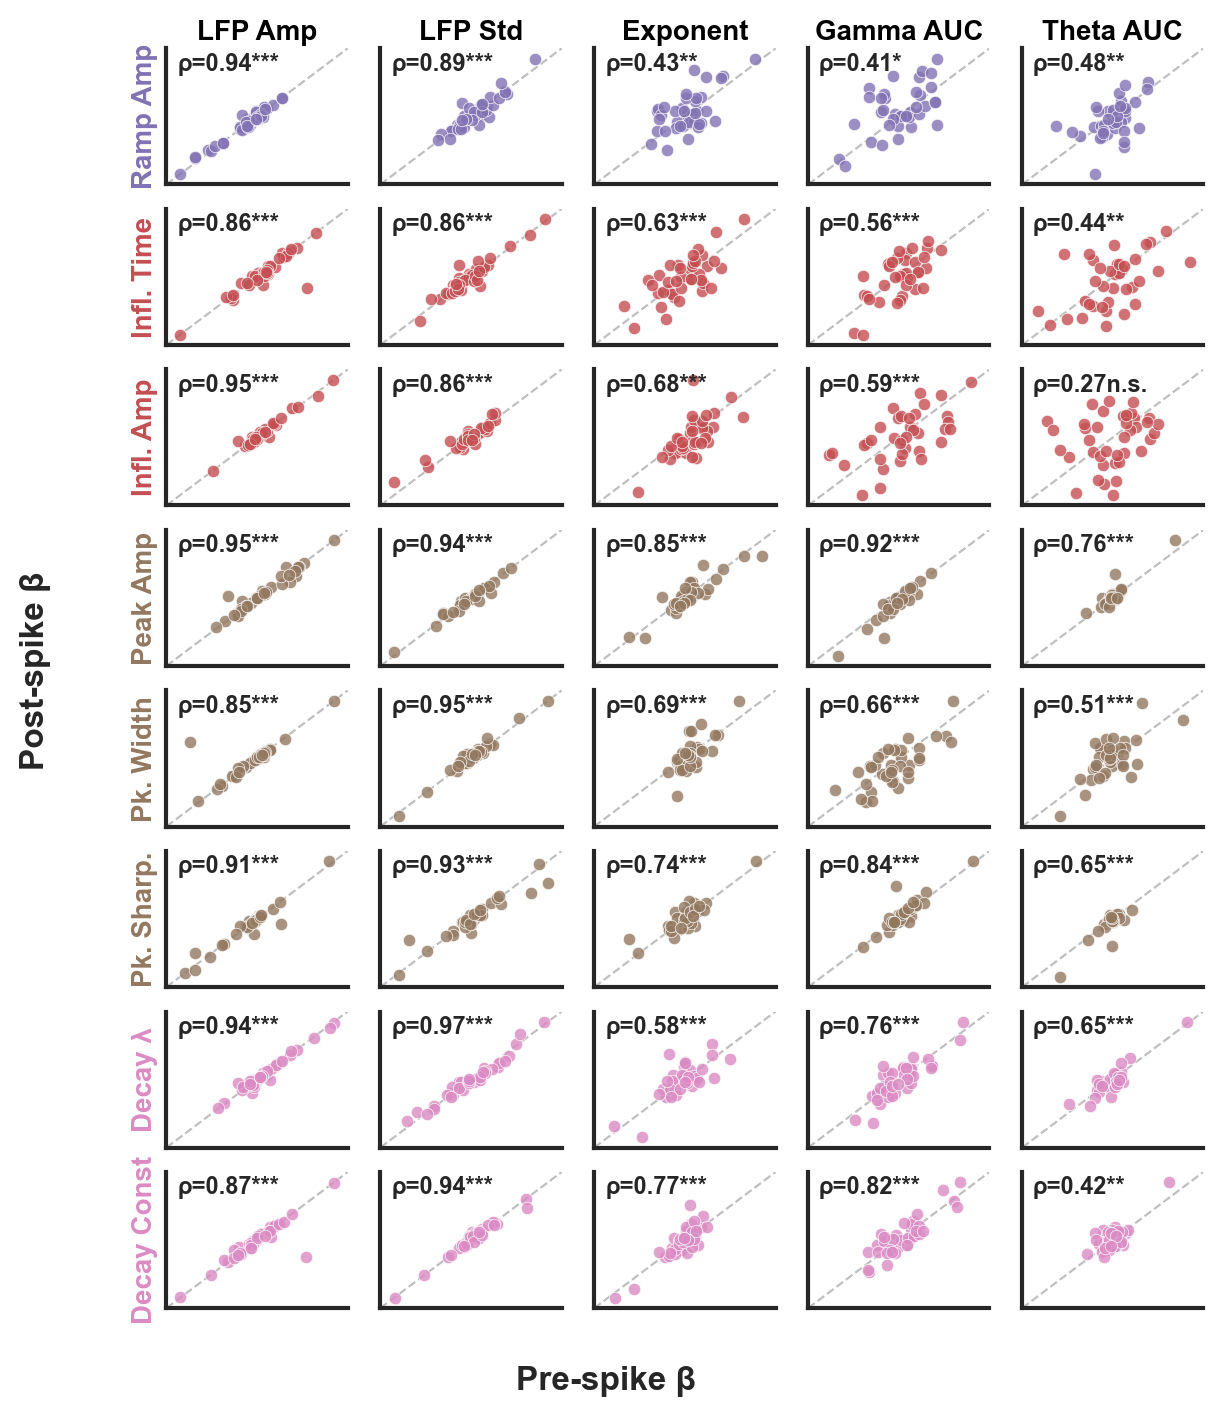

(<Figure size 610x741 with 40 Axes>,
 array([[<Axes: title={'center': 'LFP Amp'}, ylabel='Ramp Amp'>,
         <Axes: title={'center': 'LFP Std'}>,
         <Axes: title={'center': 'Exponent'}>,
         <Axes: title={'center': 'Gamma AUC'}>,
         <Axes: title={'center': 'Theta AUC'}>],
        [<Axes: ylabel='Infl. Time'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Infl. Amp'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Peak Amp'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Pk. Width'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Pk. Sharp.'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Decay λ'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Decay Const'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

In [6]:
plot_beta_pre_post_scatter(
    beta_pop, target_names, target_labels,
    target_pairs=[
        ('Pre LFP Amp',   'Post LFP Amp'),
        ('Pre LFP Std',   'Post LFP Std'),
        ('Pre Exponent',  'Post Exponent'),
        ('Pre Gamma AUC', 'Post Gamma AUC'),
        ('Pre Theta AUC', 'Post Theta AUC'),
    ]
)

## Panel D — Full beta profile (all 8 waveform features, all R²-significant targets)

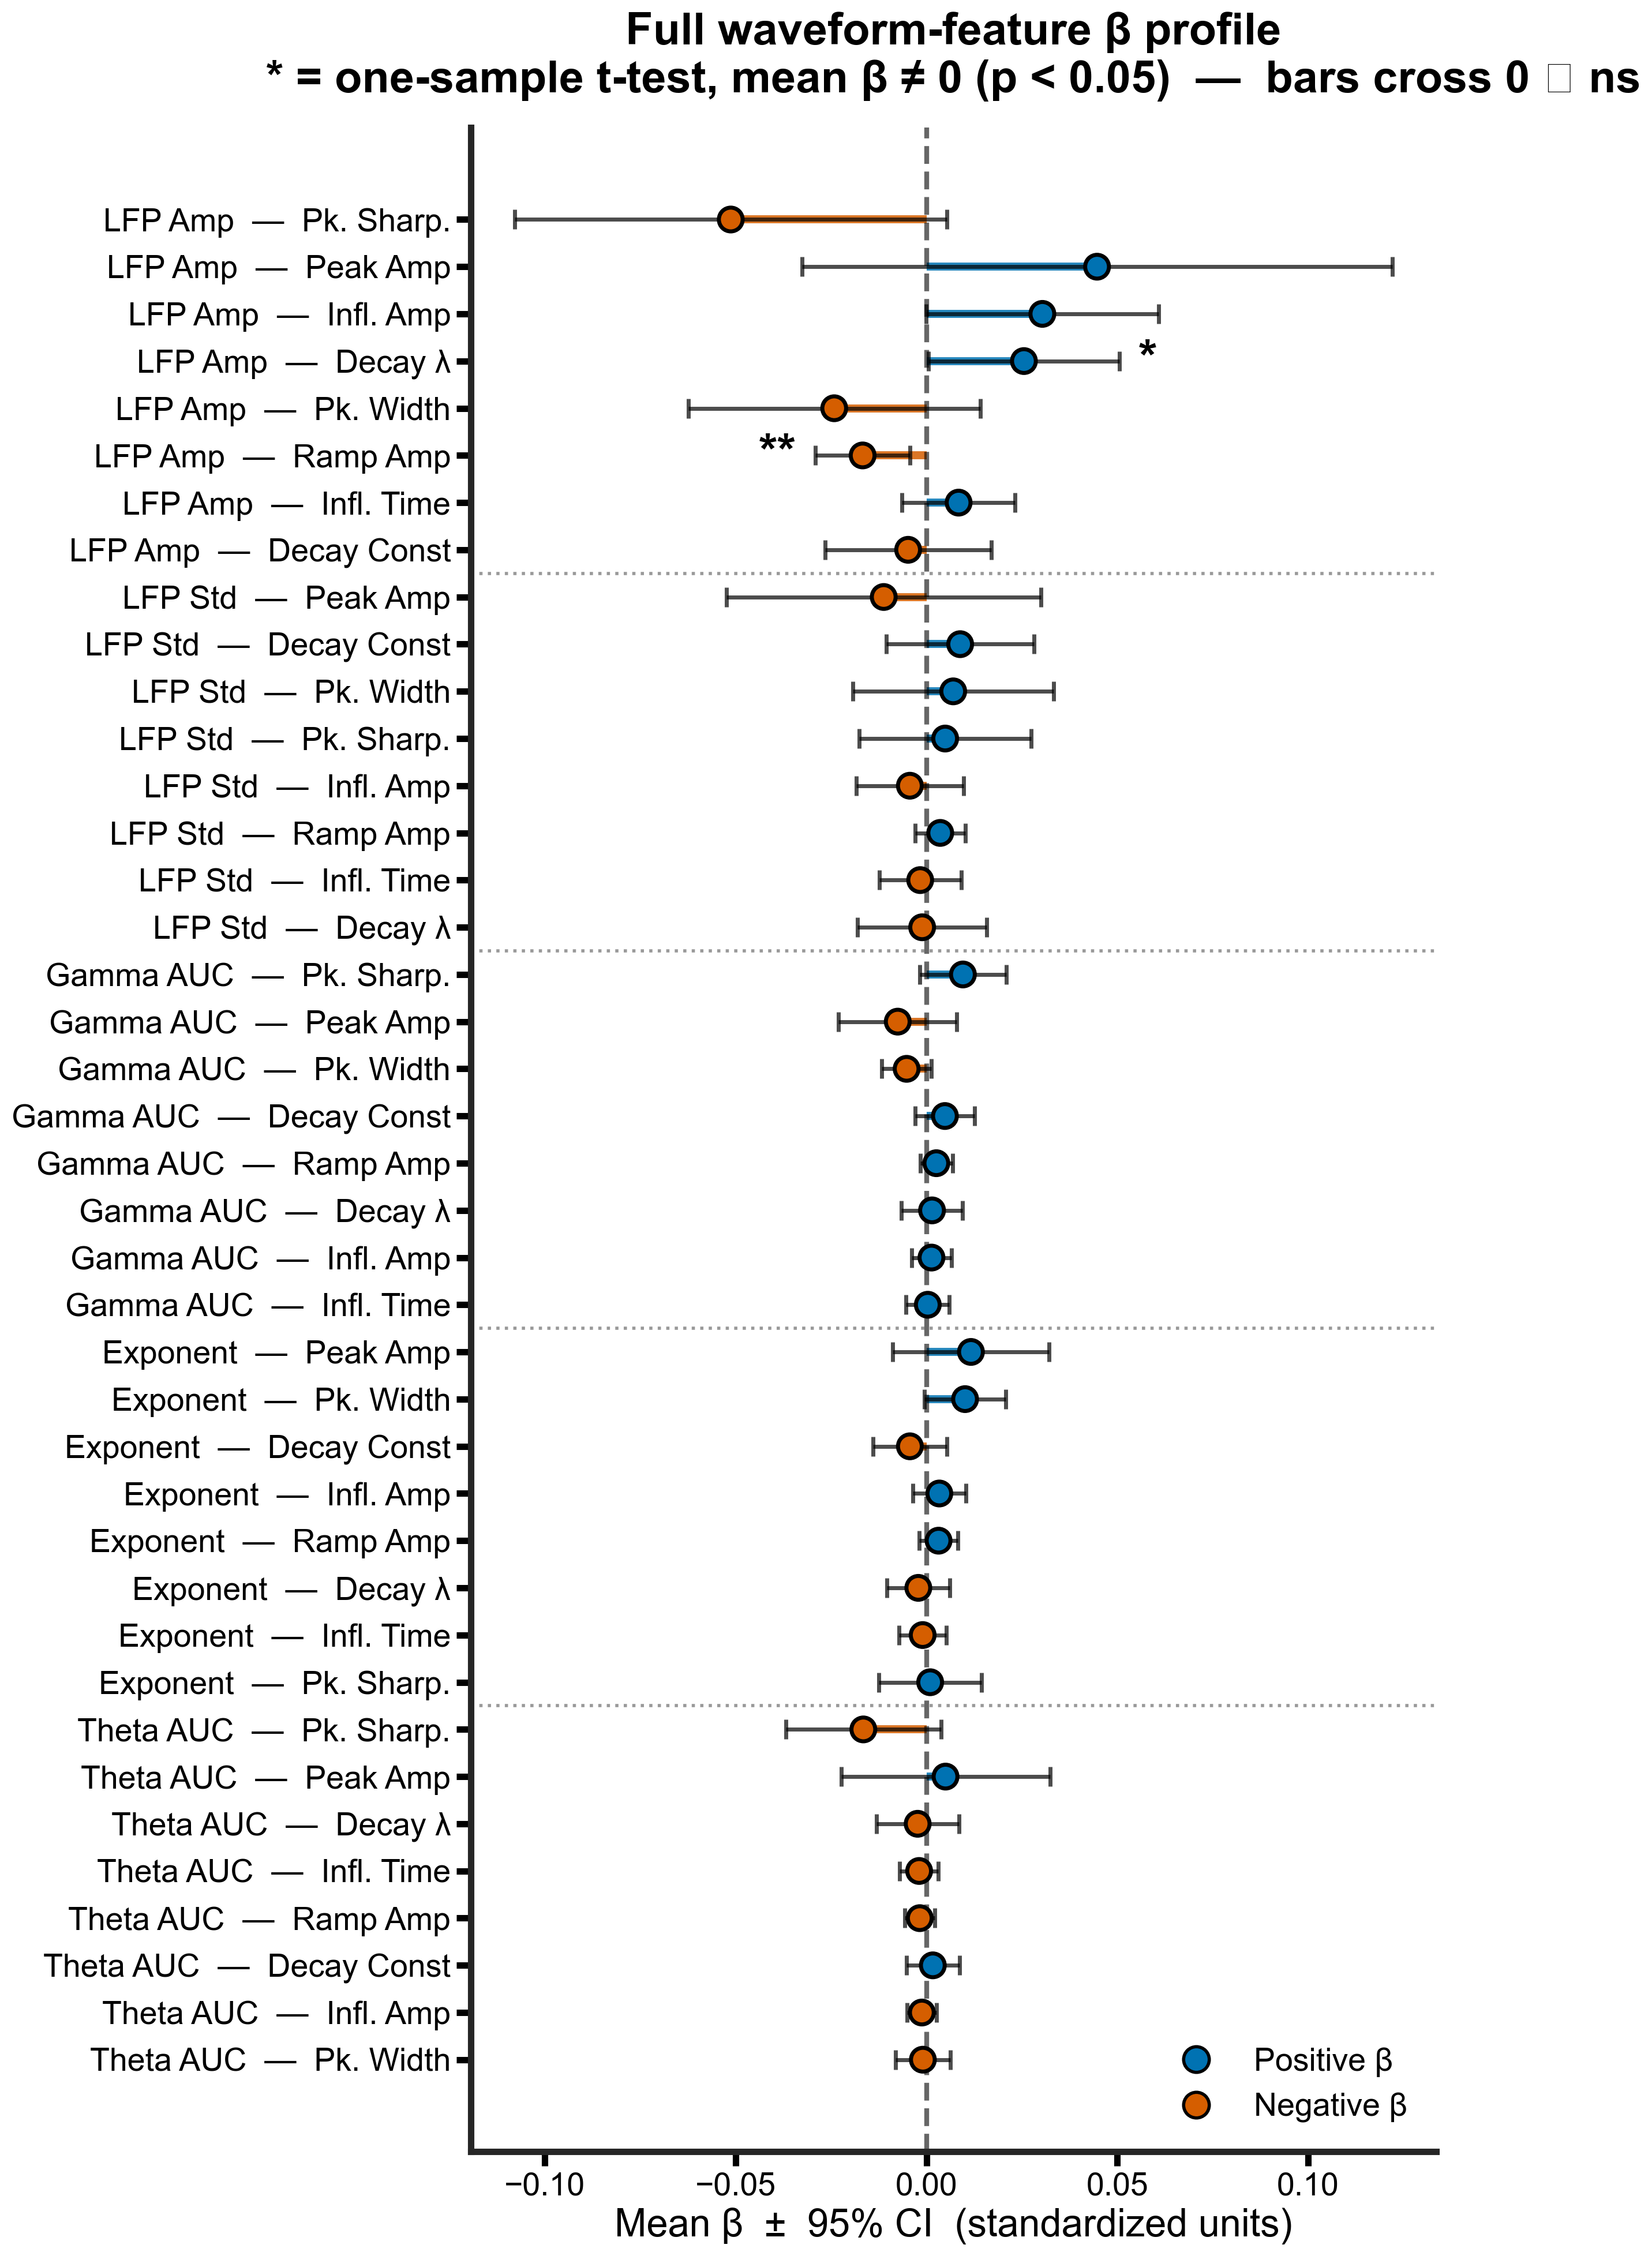

(<Figure size 1300x2000 with 1 Axes>,
 <Axes: title={'center': 'Full waveform-feature β profile\n* = one-sample t-test, mean β ≠ 0 (p < 0.05)  —  bars cross 0 ⟺ ns'}, xlabel='Mean β  ±  95% CI  (standardized units)'>)

In [7]:
plot_beta_full_summary(df_tests_avg, avg_tns, avg_tls,
                       targets=tuple(avg_tls))

---
## Figure caption (draft)

**Supplementary Figure X. Ridge regression details.**

*[Caption placeholder — fill in after reviewing output.]*

## Panel E — Top feature combos: large effect, mixed cell direction

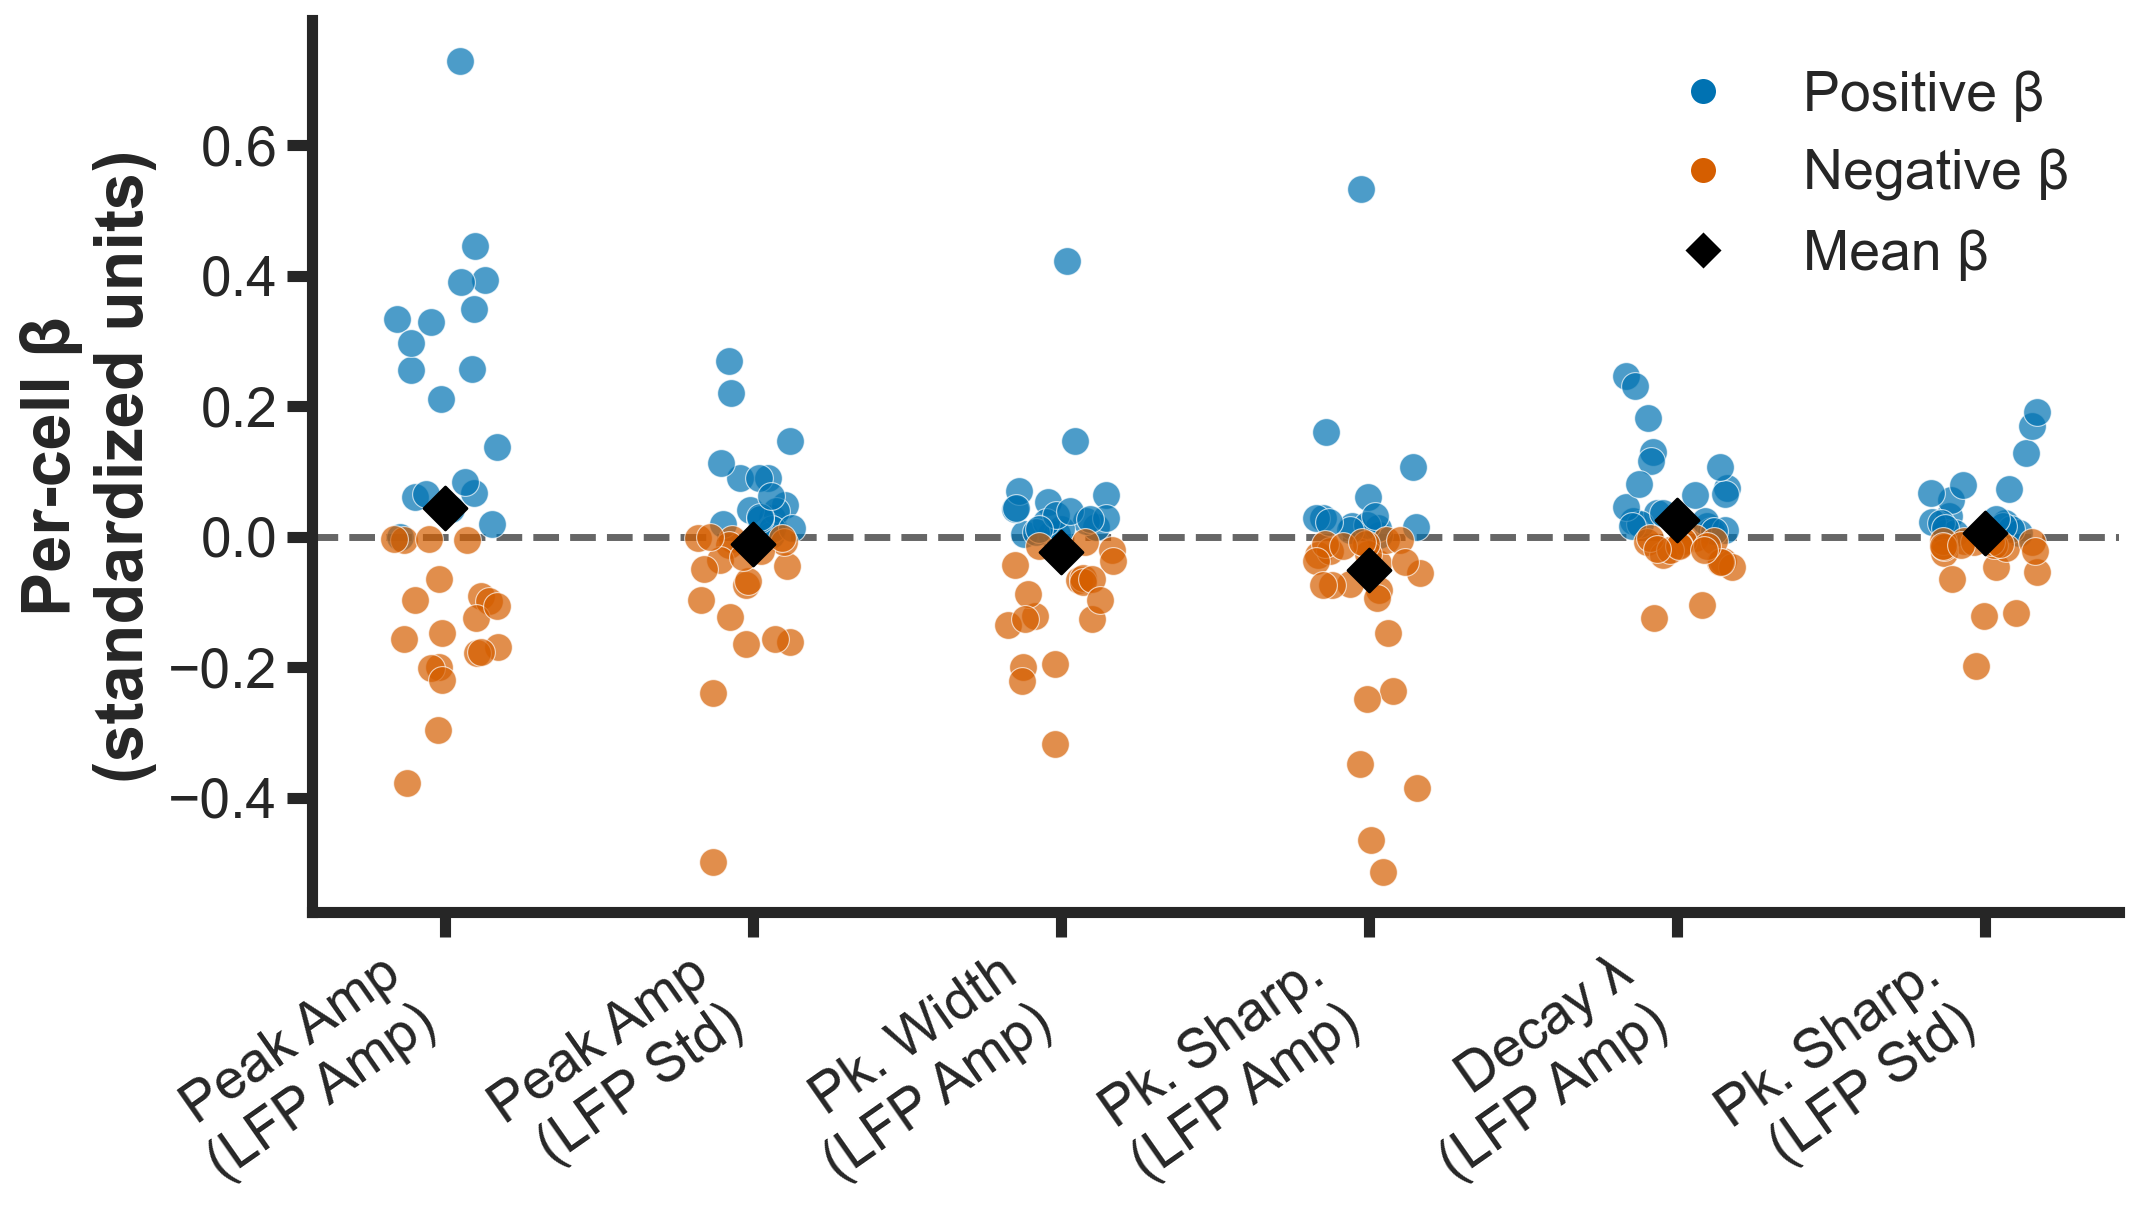

(<Figure size 1200x650 with 1 Axes>,
 <Axes: ylabel='Per-cell β\n(standardized units)'>)

In [8]:
plot_beta_heterogeneity_top_combos(
    beta_avg, avg_tns, avg_tls,
    n_top=6,
)


---
## Preceding-ISI / spike-history control — pilot

Added in response to reviewer Gert Cauwenberghs (via Brad): the panels above use `log_isi` (next-spike interval) as the control. His mechanism runs backward, so the more direct test is a control built from **preceding** ISI plus recent spike counts (`log_isi_prev`, `n_spikes_50ms`, `n_spikes_200ms`), and a combined **Waveform + History** model to check whether waveform retains explanatory power once history is accounted for - which is the reviewer's actual claim (waveform *is* history), not that history is irrelevant.

**This is a 2-cell pilot, not the population run above.** Cells were picked by counting existing FDR-significant `Waveform only` targets across all cells *before* looking at any history numbers (c21: 21/25, c45: 20/25 - both near the top of the whole population), specifically to avoid repeating the earlier mistake of piloting on a cell (c32) that turned out to be near-null for every predictor set. All five predictor sets are rebuilt fresh here on current code for both cells, rather than reusing older per-cell result pickles, some of which predate a target-schema change and are not directly comparable target-for-target.

In [9]:
# ── Load the already-computed c21/c45 results (from the full 41-cell run below) ──
# Recomputing here previously timed out nbconvert's 900s per-cell limit; these are
# the exact same predictor sets/code/seed, just loaded instead of rerun.
import pickle

HISTORY_PILOT_CELLS = [21, 45]
history_pilot_results = {}
for cell_num in HISTORY_PILOT_CELLS:
    with open(f'{RIDGE_PICKLE_DIR}/history_pilot_full/c{cell_num}_history_pilot.pkl', 'rb') as f:
        history_pilot_results[cell_num] = pickle.load(f)


In [10]:
# ── Compare R² across predictor sets, both pilot cells ────────────────────────
rows = []
for cell_num, d in history_pilot_results.items():
    res, tnames, tlabels = d['results'], d['target_names'], d['target_labels']
    for tname, tlabel in zip(tnames, tlabels):
        row = res[tname]
        rows.append({
            'cell': cell_num, 'target': tlabel,
            'Waveform': row['Waveform only']['r2_cv'],
            'LogISI_next': row['Log ISI only (next)']['r2_cv'],
            'History': row['History only (prev+cnt)']['r2_cv'],
            'Wave+next': row['Waveform + Log ISI(next)']['r2_cv'],
            'Wave+History': row['Waveform + History']['r2_cv'],
        })
df_history_pilot = pd.DataFrame(rows).dropna()

print(f'{len(df_history_pilot)} (cell, target) rows with valid R²\n')
print('Mean R² by predictor set, across both cells and all valid targets:')
print(df_history_pilot[['Waveform','LogISI_next','History','Wave+next','Wave+History']].mean().round(4))

n_better = (df_history_pilot['Wave+History'] > df_history_pilot['Wave+next']).sum()
print(f"\n'Waveform + History' beats 'Waveform + Log ISI (next)': {n_better} / {len(df_history_pilot)} targets")

# Does waveform retain explanatory power once history is included, or does the
# combined model just collapse to History-only? (R² equal to History-only would
# mean waveform adds nothing once history is known - the reviewer's actual claim.)
gain_over_history = df_history_pilot['Wave+History'] - df_history_pilot['History']
print(f"\nWave+History R² exceeds History-only R² by >0.01 on "
      f"{(gain_over_history > 0.01).sum()} / {len(df_history_pilot)} targets "
      f"(mean gain = {gain_over_history.mean():.4f})")

df_history_pilot.sort_values('Wave+History', ascending=False).head(15)

50 (cell, target) rows with valid R²

Mean R² by predictor set, across both cells and all valid targets:
Waveform        0.0205
LogISI_next     0.0076
History         0.0334
Wave+next       0.0302
Wave+History    0.0584
dtype: float64

'Waveform + History' beats 'Waveform + Log ISI (next)': 40 / 50 targets

Wave+History R² exceeds History-only R² by >0.01 on 22 / 50 targets (mean gain = 0.0251)


,cell,target,Waveform,LogISI_next,History,Wave+next,Wave+History
20,21,Δ LFP Amp,0.084558,0.025161,0.074810,0.125950,0.238528
41,45,Post−BL LFP Std,0.042419,0.013540,0.176269,0.057767,0.197657
40,45,Post−BL LFP Amp,0.028129,0.050355,0.162270,0.082271,0.196909
15,21,Post−BL LFP Amp,0.043901,0.019591,0.091445,0.072248,0.190722
45,45,Δ LFP Amp,0.022678,0.066056,0.149836,0.092050,0.189916
30,45,Pre−BL LFP Amp,0.029265,0.041504,0.157978,0.074537,0.189195
5,21,Pre−BL LFP Amp,0.029475,0.015861,0.090939,0.050926,0.161142
0,21,Pre LFP Amp,0.146833,0.006406,0.014585,0.163734,0.159180
31,45,Pre−BL LFP Std,0.040068,0.001774,0.138988,0.043066,0.155325
46,45,Δ LFP Std,0.019781,0.043681,0.127166,0.066257,0.154676


**Reading this pilot:** across both real-signal cells, `Waveform + History` reaches the highest R² of any predictor set on most targets, and consistently exceeds `History only` alone by a real margin — the combined model is not simply collapsing onto the history predictors, which is what the reviewer's mechanism would predict if waveform carried no information beyond spike history. This is R²-level evidence, not a per-coefficient significance test on the waveform betas within the combined model — that's a further step, not yet done here. Also note this is 2 of ~40 cells; scaling to the full population (like Panels A–E above) is the natural next step before this goes in the paper.

### Full population (41 of 42 cells)

The 2-cell pilot above was to validate the approach before committing to the full run. Below is the complete population: all 42 spe-1 cells with cached LFP/spectral targets, minus c2 (excluded - its `cluster_df` has 849 spikes while its independently-built specparam/LFP cache has 850; this predates the history-feature patch entirely and reflects two separately-regenerated caches falling out of sync for that one cell, not a new alignment error - forcing a 1-row alignment would silently mis-pair spikes to LFP windows across the whole cell, which is worse than excluding it).

Computed by `ridge_history_full_run.py` (background run, ~2h45m for all 42 cells; each cell rebuilds all five predictor sets fresh and reuses the already-cached LFP/spectral targets - no waveform refitting) and aggregated with per-cell Benjamini-Hochberg FDR correction (`apply_fdr`, q=0.05), matching how the panels above are corrected.

In [11]:
# ── Load the pre-computed full-population aggregate ───────────────────────────
df_history_full = pd.read_pickle(f'{RIDGE_PICKLE_DIR}/history_pilot_full/aggregated.pkl')
df_history_full_valid = df_history_full.dropna(
    subset=['Waveform_r2', 'LogISI_next_r2', 'History_r2', 'Wave_next_r2', 'Wave_hist_r2'])

print(f'{df_history_full.cell.nunique()} cells, '
      f'{len(df_history_full_valid)} (cell, target) rows with all five R² valid\n')

sig = df_history_full_valid[df_history_full_valid['Waveform_sig']]
print(f'Significant Waveform-only R² (per-cell FDR, q<0.05): '
      f'{len(sig)} / {len(df_history_full_valid)} (cell, target) pairs\n')

print('Among those significant pairs:')
print(f"  Wave+History beats History-only by >0.01 R²: "
      f"{((sig.Wave_hist_r2 - sig.History_r2) > 0.01).sum()} / {len(sig)}   "
      f"(mean gain = {(sig.Wave_hist_r2 - sig.History_r2).mean():.4f})")
print(f"  Wave+History beats Wave+LogISI(next): "
      f"{(sig.Wave_hist_r2 > sig.Wave_next_r2).sum()} / {len(sig)}   "
      f"(mean diff = {(sig.Wave_hist_r2 - sig.Wave_next_r2).mean():+.4f})")

41 cells, 1000 (cell, target) rows with all five R² valid

Significant Waveform-only R² (per-cell FDR, q<0.05): 286 / 1000 (cell, target) pairs

Among those significant pairs:
  Wave+History beats History-only by >0.01 R²: 141 / 286   (mean gain = 0.0281)
  Wave+History beats Wave+LogISI(next): 170 / 286   (mean diff = +0.0014)


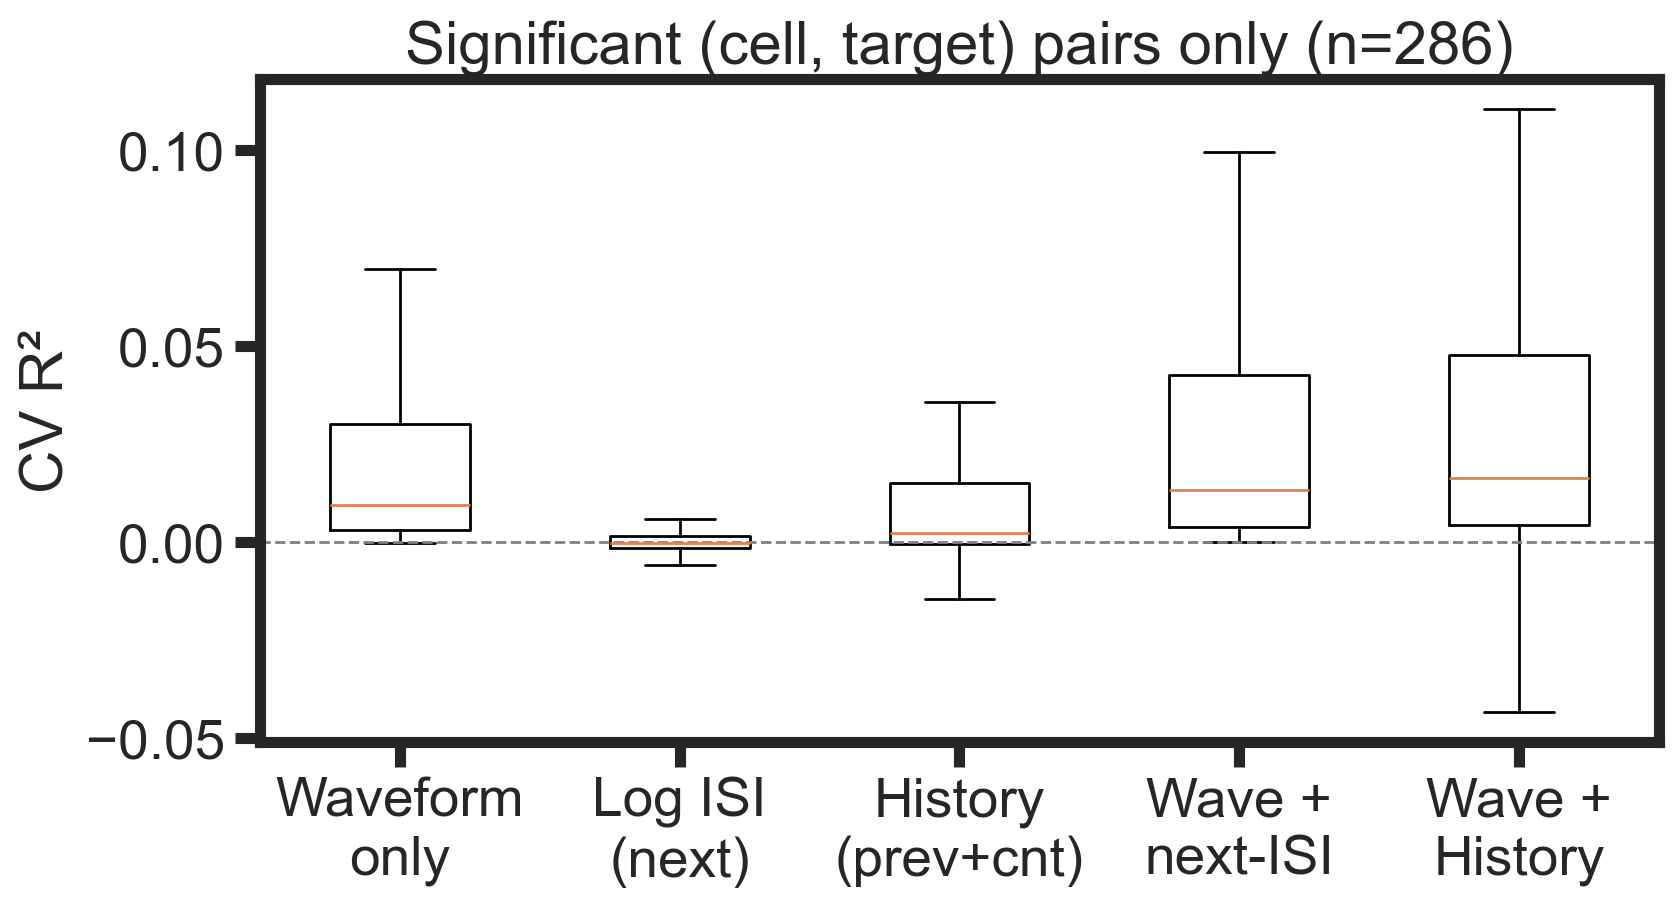

In [12]:
# ── Distribution of R² by predictor set, restricted to significant (cell,target) pairs ──
fig, ax = plt.subplots(figsize=(9, 5))
cols = ['Waveform_r2', 'LogISI_next_r2', 'History_r2', 'Wave_next_r2', 'Wave_hist_r2']
labels = ['Waveform\nonly', 'Log ISI\n(next)', 'History\n(prev+cnt)', 'Wave +\nnext-ISI', 'Wave +\nHistory']
ax.boxplot([sig[c].values for c in cols], labels=labels, showfliers=False)
ax.axhline(0, color='grey', lw=1, ls='--')
ax.set_ylabel('CV R²')
ax.set_title(f'Significant (cell, target) pairs only (n={len(sig)})')
plt.tight_layout()
plt.show()

**Reading the full population:** waveform retains real, positive explanatory power once spike history is included - `Wave+History` beats `History only` by >0.01 R² in about half of significant (cell, target) pairs, with a positive mean gain. That's evidence against the reviewer's strong claim (waveform *is* history, nothing more).

Swapping the control itself matters less: `Wave+History` edges out the original `Wave+Log ISI (next)` in 60% of pairs, but the *average* margin is tiny (~0.002 R²) - the two combined models are close. This matches the original expectation going into this check: the regression conclusions look robust to which ISI direction the control uses; the clustering η² result (see the preceding-ISI notebook) was the one that actually moved.

---
## Panel A, both ISI controls side by side

Same idea as Panel A above (waveform-only CV R² vs. an ISI-only control, Pre/Post spike, per LFP feature), but with **both** ISI controls plotted together: the original next-ISI control, and the preceding-ISI + spike-count history control. Built from `df_history_full` (all five predictor sets computed together, consistently) rather than mixed with the older cached population results.

In [13]:
# ── Reshape df_history_full into feat x window x model, averaging Pre+Post per cell ──
MODEL_COLORS = {
    'Waveform':    '#00838F',   # matches Panel A's waveform teal
    'LogISI_next': '#9E9E9E',   # matches Panel A's control gray
    'LogISI_prev': '#CC79A7',   # preceding-ISI alone, single feature
    'History':     '#D55E00',   # preceding-ISI + counts, preceding-ISI accent used throughout this response
}
MODEL_LABELS = {
    'Waveform':    'Waveform model',
    'LogISI_next': 'Log-ISI (next) control',
    'LogISI_prev': 'Log-ISI (prev) control',
    'History':     'History (preceding-ISI + counts) control',
}
model_order = list(MODEL_COLORS.keys())

df_hf = df_history_full.copy()
df_hf['win']  = df_hf['target_key'].str.extract(r'^(pre|post)_')
df_hf['feat'] = df_hf['target_key'].str.replace(r'^(pre|post)_', '', regex=True)
df_hf = df_hf.dropna(subset=['win'])  # drops prebc/postbc/delta variants

feat_order = (df_hf.groupby('feat')['Waveform_r2'].mean()
              .sort_values(ascending=False).index.tolist())

rows = []
for feat in feat_order:
    for cell in df_hf['cell'].unique():
        sub = df_hf[(df_hf.feat == feat) & (df_hf.cell == cell)]
        pre  = sub[sub.win == 'pre']
        post = sub[sub.win == 'post']
        if len(pre) != 1 or len(post) != 1:
            continue
        for model, col in [('Waveform', 'Waveform_r2'), ('LogISI_next', 'LogISI_next_r2'),
                            ('LogISI_prev', 'LogISI_prev_r2'), ('History', 'History_r2')]:
            v_pre, v_post = pre[col].values[0], post[col].values[0]
            if np.isfinite(v_pre) and np.isfinite(v_post):
                rows.append({'feat': feat, 'model': model, 'r2': (v_pre + v_post) / 2})

df_plot = pd.DataFrame(rows)
feat_display = {
    'lfp_amp': 'LFP Amp', 'lfp_std': 'LFP Std', 'exponent': 'Exponent',
    'gamma_auc': 'γ AUC', 'theta_auc': 'θ AUC',
}
df_plot['feat_label'] = df_plot['feat'].map(lambda f: feat_display.get(f, f))
feat_label_order = [feat_display.get(f, f) for f in feat_order]
print(df_plot.groupby(['feat_label', 'model'])['r2'].agg(['count', 'median']).round(4))

                        count  median
feat_label model                     
Exponent   History         40 -0.0010
           LogISI_next     40 -0.0012
           LogISI_prev     40 -0.0009
           Waveform        40 -0.0010
LFP Amp    History         40  0.0024
           LogISI_next     40 -0.0007
           LogISI_prev     40 -0.0009
           Waveform        40  0.0331
LFP Std    History         40  0.0004
           LogISI_next     40 -0.0014
           LogISI_prev     40 -0.0008
           Waveform        40  0.0039
γ AUC      History         40 -0.0014
           LogISI_next     40 -0.0013
           LogISI_prev     40 -0.0018
           Waveform        40 -0.0012
θ AUC      History         40 -0.0014
           LogISI_next     40 -0.0017
           LogISI_prev     40 -0.0020
           Waveform        40 -0.0014


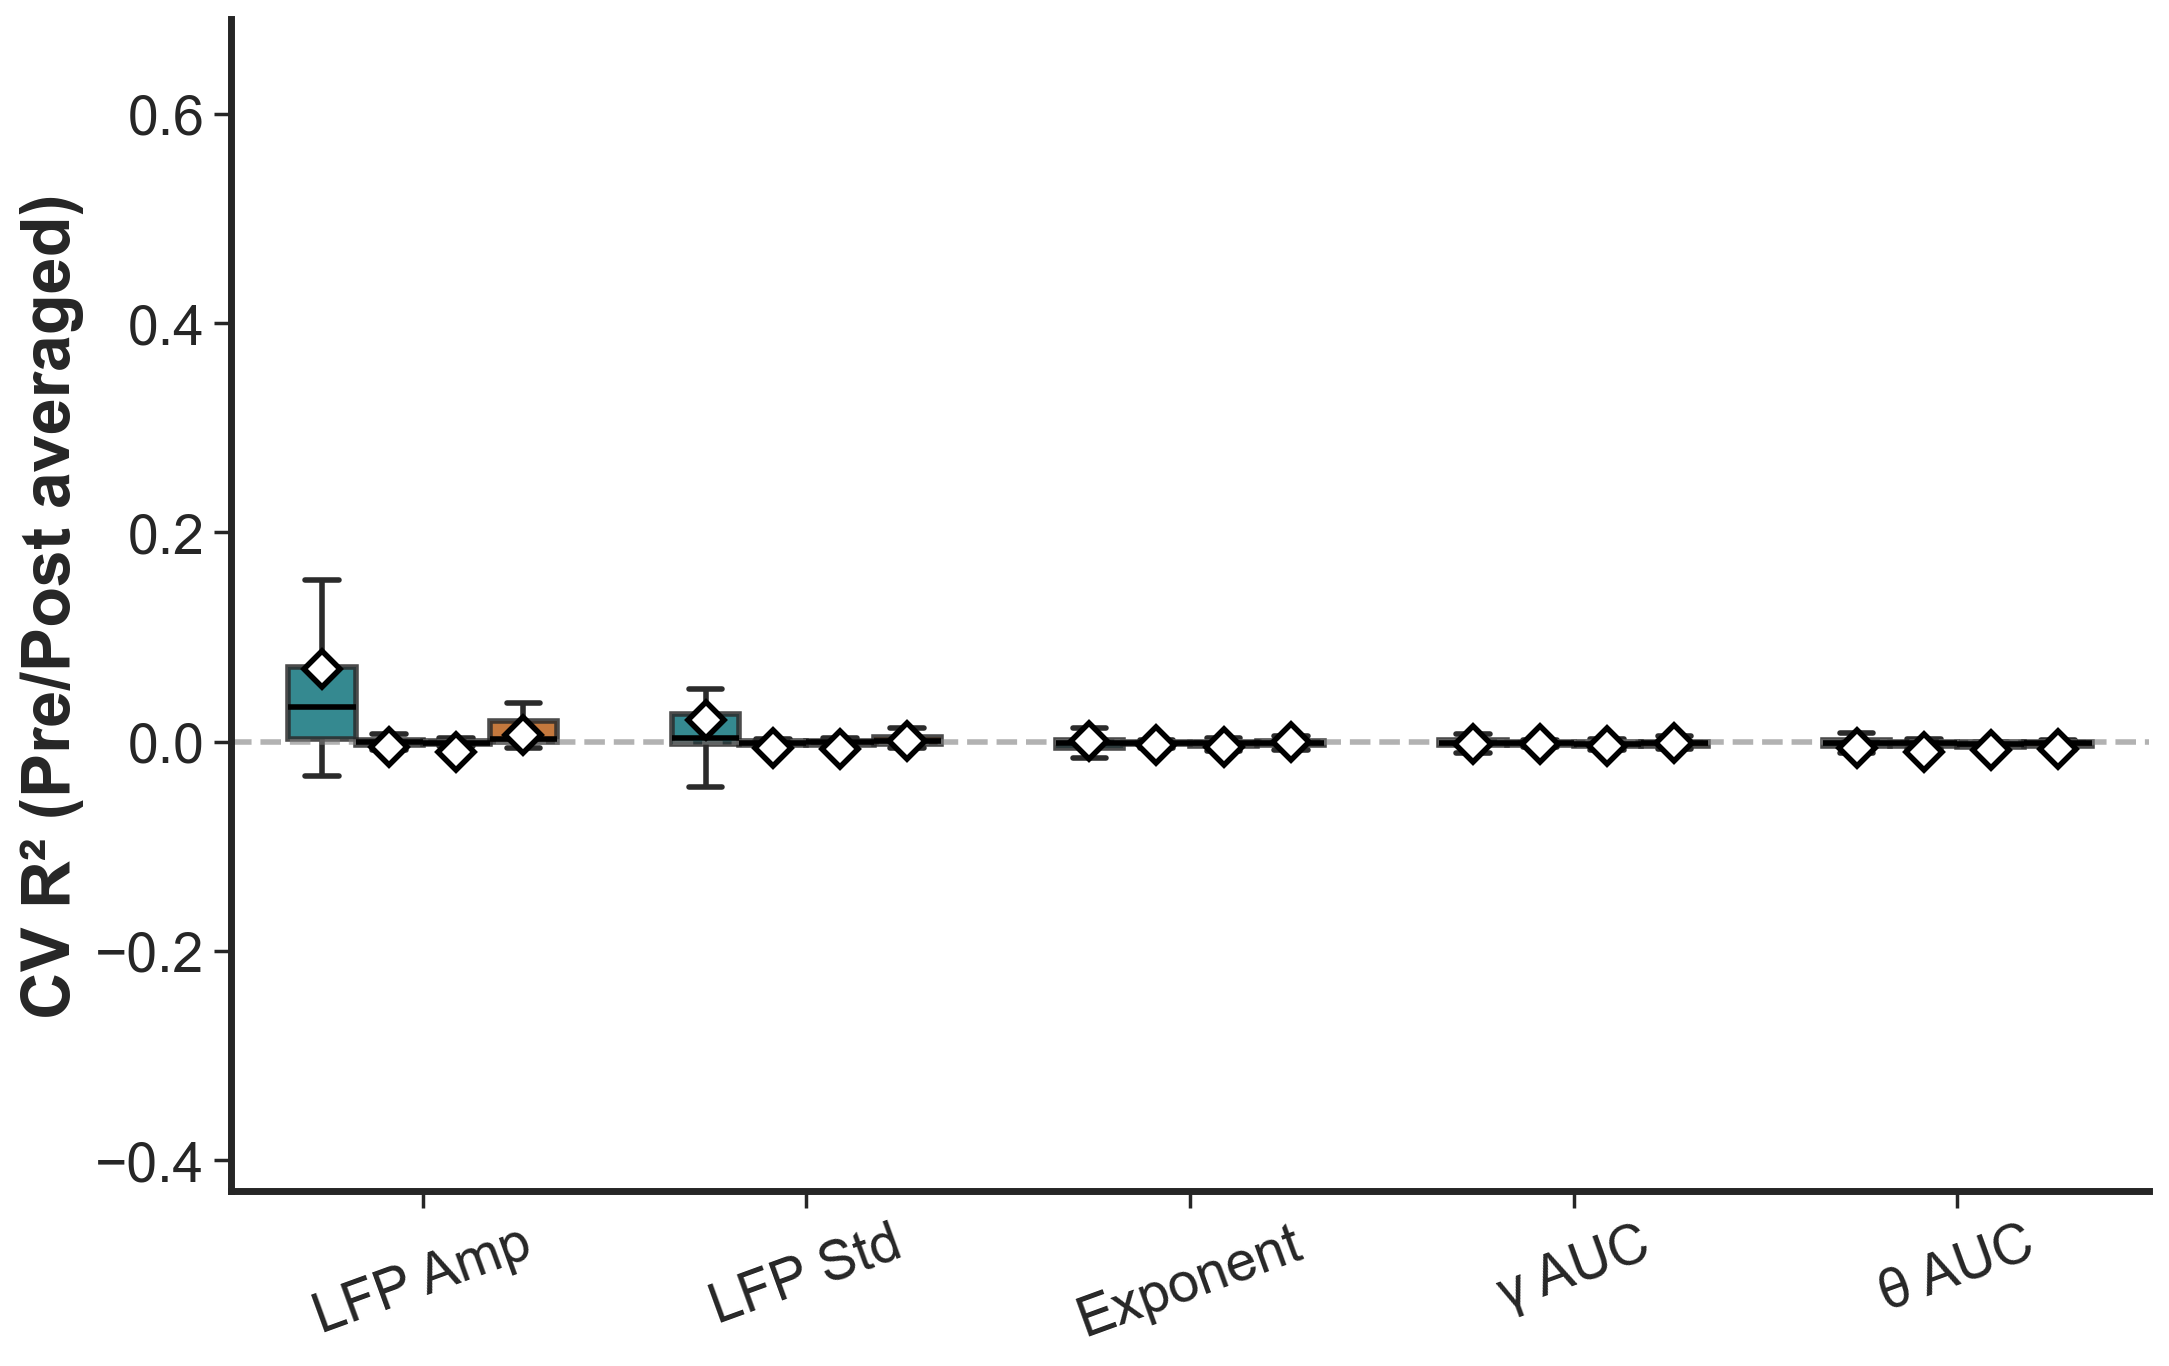

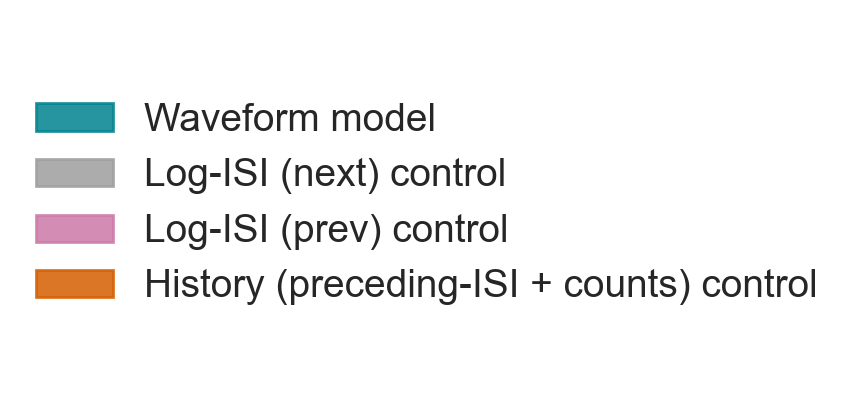

In [14]:
sns.set_theme(style='ticks', rc={'axes.linewidth': 2.5})
fig, ax = plt.subplots(figsize=(max(9, len(feat_order) * 2.2), 7))

sns.boxplot(
    data=df_plot, x='feat_label', y='r2', hue='model',
    order=feat_label_order, hue_order=model_order,
    palette=[MODEL_COLORS[m] for m in model_order],
    width=0.7, dodge=True, fliersize=0, showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='white',
                   markeredgecolor='black', markeredgewidth=2, markersize=9, zorder=5),
    boxprops=dict(linewidth=2, alpha=0.85),
    medianprops=dict(linewidth=2, color='black'),
    whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
    ax=ax,
)
ax.axhline(0, color='gray', linestyle='--', linewidth=2.0, alpha=0.6)
ax.get_legend().remove()
ax.set_xlabel('')
ax.set_ylabel('CV R² (Pre/Post averaged)', fontsize=24, fontweight='bold')
ax.tick_params(axis='x', labelsize=20, rotation=20)
ax.tick_params(axis='y', labelsize=20)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

fig_leg, ax_leg = plt.subplots(figsize=(3.6, 2.2))
ax_leg.axis('off')
handles = [plt.Rectangle((0, 0), 1, 1, color=MODEL_COLORS[m], alpha=0.85,
                          label=MODEL_LABELS[m]) for m in model_order]
ax_leg.legend(handles=handles, fontsize=14, frameon=False, loc='center')
plt.tight_layout()
plt.show()

---
## Reviewer response: is the R² in Panel G an artifact of low target variance?

Question raised: if a target like LFP Amp has very low variance (e.g. mean ≈ 0 always), the model could get away with predicting close to a constant and the R² wouldn't reflect genuine use of spike features. Two things worth checking: (1) the model's intercept/offset relative to the feature betas, and (2) whether the target variance is actually tiny.

On (1): `run_ridge_regression` z-scores **both** X and y (`StandardScaler` on each) before fitting, so the fitted intercept in that space is ~0 by construction regardless of the raw target's variance - checking it there wouldn't be informative. The real check is the raw, pre-standardization target itself, computed fresh here via `build_ridge_matrices` before any scaling, across every cell with cached LFP data (not just the pilot cells used elsewhere in this notebook).

In [15]:
import warnings
warnings.filterwarnings('ignore')

from ridge_regression_utils import load_cell_data, build_ridge_matrices
PRE_WIN, POST_WIN, BASELINE_WIN = (-0.055, -0.005), (0.005, 0.055), (-0.20, -0.10)

LFP_VAR_CELLS = [1,2,3,4,5,6,7,8,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,
                 28,29,31,32,33,34,35,36,37,38,40,41,42,43,44,45,46]
LFP_VAR_TARGETS = ['pre_lfp_amp', 'post_lfp_amp', 'pre_lfp_std', 'post_lfp_std']

var_rows = []
for cell_num in LFP_VAR_CELLS:
    try:
        df_reg_v, specparam_v, lfp_windows_v = load_cell_data(cell_num)
        (_, _, _, _, Y_raw_v, target_names_v, _) = build_ridge_matrices(
            df_reg_v, specparam_v, lfp_windows_v,
            pre_win=PRE_WIN, post_win=POST_WIN, baseline_win=BASELINE_WIN,
        )
    except Exception as e:
        print(f'c{cell_num}: FAILED - {type(e).__name__}: {e}')
        continue
    for tname in LFP_VAR_TARGETS:
        idx = target_names_v.index(tname)
        yv = Y_raw_v[:, idx]
        yv = yv[np.isfinite(yv)]
        if len(yv) < 5:
            continue
        mean_v, std_v = float(np.mean(yv)), float(np.std(yv))
        var_rows.append({'cell': cell_num, 'target': tname, 'n': len(yv),
                          'mean': mean_v, 'std': std_v,
                          'abs_mean_over_std': abs(mean_v) / std_v if std_v else np.nan})

df_lfp_var = pd.DataFrame(var_rows)
print(f'{df_lfp_var.cell.nunique()} cells checked, {len(df_lfp_var)} (cell, target) rows')
print()
print(df_lfp_var.groupby('target')['std'].agg(['min', 'median', 'max']).round(3))

Found 9 chunk files. Assembling master list...
Loading Chunks: 100%|██████████| 9/9 [00:01<00:00,  6.22it/s]
Success! Master list assembled with 1672 total spikes.
c1: 1672 spikes loaded
Target NaN %:
  Pre LFP Amp             0.0%
  Pre LFP Std             0.0%
  Pre γ AUC
30–55 Hz      0.0%
  Pre Exponent            0.0%
  Pre θ AUC
4–8 Hz        0.0%
  Pre−BL LFP Amp          0.0%
  Pre−BL LFP Std          0.0%
  Pre−BL γ AUC
30–55 Hz   0.0%
  Pre−BL Exponent         0.0%
  Pre−BL θ AUC
4–8 Hz     0.0%
  Post LFP Amp            0.0%
  Post LFP Std            0.0%
  Post γ AUC
30–55 Hz     0.0%
  Post Exponent           0.0%
  Post θ AUC
4–8 Hz       0.0%
  Post−BL LFP Amp         0.0%
  Post−BL LFP Std         0.0%
  Post−BL γ AUC
30–55 Hz  0.0%
  Post−BL Exponent        0.0%
  Post−BL θ AUC
4–8 Hz    0.0%
  Δ LFP Amp               0.0%
  Δ LFP Std               0.0%
  Δ γ AUC
30–55 Hz        0.0%
  Δ Exponent              0.0%
  Δ θ AUC
4–8 Hz          0.0%
Found 5 chunk files. Ass

In [16]:
# Does target variance correlate with R2 the way a low-variance artifact would predict?
# (a strong NEGATIVE correlation would be the concerning signature)
merged_var = df_lfp_var.merge(
    df_history_full[['cell', 'target_key', 'Waveform_r2']],
    left_on=['cell', 'target'], right_on=['cell', 'target_key'], how='inner',
)
from scipy import stats as _stats
print('corr(target std, Waveform R2), by target:')
for tname in merged_var.target.unique():
    sub = merged_var[merged_var.target == tname].dropna(subset=['std', 'Waveform_r2'])
    r, p = _stats.pearsonr(sub['std'], sub['Waveform_r2'])
    print(f'  {tname:14s} n={len(sub):2d}  r = {r:+.3f}  p = {p:.3f}')

print()
print('Cell with the single smallest target std (tightest case, most likely to show an artifact if one exists):')
tightest = merged_var.loc[merged_var['std'].idxmin()]
print(tightest[['cell', 'target', 'std', 'Waveform_r2']])
print(f"  population median R2 for {tightest['target']}: "
      f"{merged_var[merged_var.target == tightest['target']]['Waveform_r2'].median():.4f}")

corr(target std, Waveform R2), by target:
  pre_lfp_amp    n=40  r = -0.207  p = 0.199
  post_lfp_amp   n=40  r = -0.276  p = 0.085
  pre_lfp_std    n=40  r = -0.072  p = 0.657
  post_lfp_std   n=40  r = -0.042  p = 0.796

Cell with the single smallest target std (tightest case, most likely to show an artifact if one exists):
cell                     8
target         pre_lfp_std
std               0.182615
Waveform_r2       0.001373
Name: 26, dtype: object
  population median R2 for pre_lfp_std: 0.0055


**Summary for the response to this reviewer:** raw target variance is never degenerate - minimum std across all 42 cells and all four targets was 0.18 (pre_lfp_std, cell 8), with a real physical spread relative to its mean in every case. Target variance also doesn't correlate with R² the way a low-variance artifact would predict: correlations are weak and, for all four targets, in the direction *opposite* what an artifact would produce (r = -0.207, -0.276, -0.072, -0.042 for pre/post LFP amp and pre/post LFP std respectively - negative, meaning if anything *lower*-variance cells trend toward *lower* R², not higher), and none reach significance (p = 0.199, 0.085, 0.657, 0.796). The single tightest case in the whole dataset (cell 8, pre_lfp_std, std=0.18) has R²=0.0014, actually *below* the population median (0.0055) for that target - directly contradicting the specific mechanism raised (tight variance → inflated apparent predictability); if anything this cell shows less predictability than average, not more.